## 1 - Packages
Run the cell below to import all the libraries:

In [25]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import BatchNormalization 
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflowjs as tfjs

## 2 - Load and Split the Data

In [2]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import imageio.v2 as imageio

import matplotlib.pyplot as plt
%matplotlib inline

dataset_path = "dataset/mnist/"

labels_df = pd.read_csv(dataset_path + "labels.csv")
image_list = list(map(lambda x: dataset_path+x , labels_df.iloc[:,0].values))
labels = labels_df.iloc[:,1].values

#### Check out the some of the digits in the dataset :
Modify '*N*' to display another digit.

(-0.5, 27.5, 27.5, -0.5)

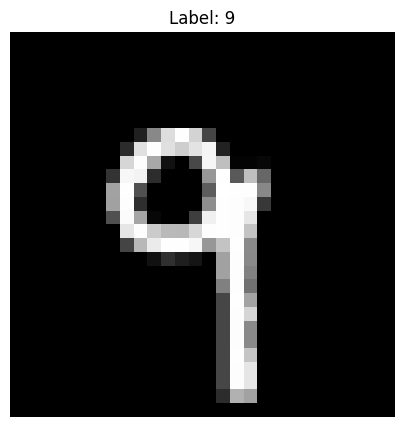

In [3]:
N = 1255
img = imageio.imread(image_list[N])
lbl = labels[N]

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title(f"Label: {lbl}")
plt.axis('off')

### 2.1 - Create Tensorflow Dataset

In [4]:
image_list_ds = tf.data.Dataset.list_files(image_list, shuffle=False)
image_filenames = tf.constant(image_list)

dataset = tf.data.Dataset.from_tensor_slices((image_filenames, labels))

for image, label in dataset.take(1):
    print(image)
    print(label)

tf.Tensor(b'dataset/mnist/0.png', shape=(), dtype=string)
tf.Tensor(7, shape=(), dtype=int64)


2023-08-31 19:33:23.982193: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-08-31 19:33:24.003653: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-08-31 19:33:24.003851: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [38]:
def process_path(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    
    one_hot_label = tf.one_hot(label, depth=10)
    
    return img, one_hot_label

mnist_ds = dataset.map(process_path)

# Split the dataset into training and testing sets
train_size = int(0.9 * len(mnist_ds))
test_size = len(mnist_ds) - train_size

train_dataset = mnist_ds.take(train_size)
test_dataset = mnist_ds.skip(train_size)

XTrain = []
YTrain = []

for features, labels in train_dataset:
    XTrain.append(features.numpy())  # Convert to numpy array and append to XTrain
    YTrain.append(labels.numpy())     # Convert to numpy array and append to YTrain
    
XTrain = np.array(XTrain)
YTrain = np.array(YTrain)

## 3 - Convolutional Neural Network Model

In [22]:
def conv_net_model(input_size=(28, 28, 1), n_classes=10):
    """
    conv_net_model
    
    Arguments:
        input_size -- Input shape 
        n_classes -- Number of output classes
    Returns: 
        model -- tf.keras.Model
    """
    
    inputs = Input(input_size)
    
    layer = Conv2D(32, 
                   kernel_size=3,      
                   activation='relu',
                   kernel_initializer='he_normal')(inputs)    
    layer = BatchNormalization()(layer)    
    layer = Conv2D(32, 
                   kernel_size=3,      
                   activation='relu',
                   kernel_initializer='he_normal')(layer)   
    layer = BatchNormalization()(layer)   
    layer = Conv2D(32, 
                   kernel_size=5,
                   strides=2,
                   activation='relu',
                   padding='same',
                   kernel_initializer='he_normal')(layer)   
    layer = BatchNormalization()(layer) 
    layer = Dropout(0.4)(layer)
    
    
    layer = Conv2D(64, 
                   kernel_size=3,      
                   activation='relu',
                   kernel_initializer='he_normal')(layer)    
    layer = BatchNormalization()(layer)    
    layer = Conv2D(64, 
                   kernel_size=3,      
                   activation='relu',
                   kernel_initializer='he_normal')(layer)   
    layer = BatchNormalization()(layer)   
    layer = Conv2D(64, 
                   kernel_size=5,
                   strides=2,
                   activation='relu',
                   padding='same',
                   kernel_initializer='he_normal')(layer)   
    layer = BatchNormalization()(layer) 
    layer = Dropout(0.4)(layer)
    
    layer = Flatten()(layer)
    layer = Dense(units=128,
                  activation='relu',
                  kernel_initializer='he_normal') (layer)
    layer = BatchNormalization()(layer)
    layer = Dropout(0.4)(layer)
    
    outputs = Dense(units=n_classes, 
                    activation='softmax')(layer)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    return model

In [23]:
model = conv_net_model()
model.summary()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_16 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 batch_normalization_14 (Ba  (None, 26, 26, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_17 (Conv2D)          (None, 24, 24, 32)        9248      
                                                                 
 batch_normalization_15 (Ba  (None, 24, 24, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_18 (Conv2D)          (None, 12, 12, 32)        2563

In [43]:
EPOCHS = 15
VAL_SUBSPLITS = 5
BUFFER_SIZE = 500
BATCH_SIZE = 64

datagen = ImageDataGenerator(
        rotation_range=10,  
        zoom_range = 0.1,  
        width_shift_range=0.1, 
        height_shift_range=0.1)

#train_dataset_batch = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
test_dataset_batch = test_dataset.batch(BATCH_SIZE)
model_history = model.fit_generator(datagen.flow(XTrain,YTrain, batch_size=BATCH_SIZE), epochs=EPOCHS, validation_data=test_dataset_batch)

Epoch 1/15
  5/845 [..............................] - ETA: 12s - loss: 0.0261 - accuracy: 0.9906

/tmp/ipykernel_86418/3366711909.py:14: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model_history = model.fit_generator(datagen.flow(XTrain,YTrain, batch_size=BATCH_SIZE), epochs=EPOCHS, validation_data=test_dataset_batch)


845/845 [==============================] - 14s 16ms/step - loss: 0.0311 - accuracy: 0.9908 - val_loss: 0.0208 - val_accuracy: 0.9930
Epoch 2/15
845/845 [==============================] - 14s 16ms/step - loss: 0.0280 - accuracy: 0.9915 - val_loss: 0.0169 - val_accuracy: 0.9952
Epoch 3/15
845/845 [==============================] - 14s 17ms/step - loss: 0.0283 - accuracy: 0.9915 - val_loss: 0.0194 - val_accuracy: 0.9938
Epoch 4/15
845/845 [==============================] - 14s 16ms/step - loss: 0.0275 - accuracy: 0.9917 - val_loss: 0.0178 - val_accuracy: 0.9947
Epoch 5/15
845/845 [==============================] - 14s 17ms/step - loss: 0.0277 - accuracy: 0.9917 - val_loss: 0.0201 - val_accuracy: 0.9938
Epoch 6/15
845/845 [==============================] - 14s 17ms/step - loss: 0.0277 - accuracy: 0.9916 - val_loss: 0.0161 - val_accuracy: 0.9950
Epoch 7/15
845/845 [==============================] - 14s 16ms/step - loss: 0.0260 - accuracy: 0.9921 - val_loss: 0.0198 - val_accuracy: 0.9945
Epo

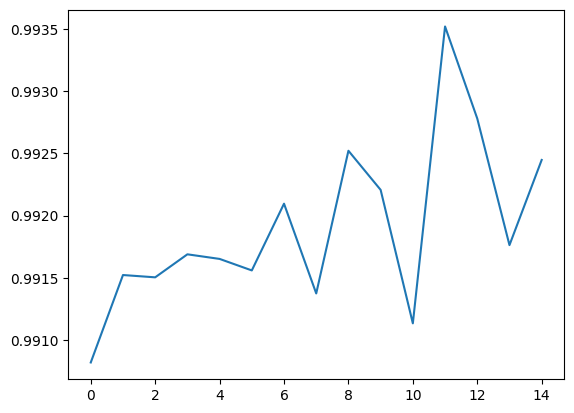

In [44]:
plt.plot(model_history.history["accuracy"])

In [45]:
# Save the model in SavedModel format
tfjs.converters.save_keras_model(model, "saved_models/")

(54018, 28, 28, 1)